# CS459 - Business Intelligence
## Project: Telecom Customer Churn Analysis
### Data Wrangling & Exploratory Data Analysis (EDA)
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mano
from scipy.stats import zscore
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

%matplotlib inline
sns.set(style='whitegrid')
print('Libraries imported successfully')

Libraries imported successfully


## Step 1: Discovering the Data
### 1.1 Load Dataset

In [3]:
df= pd.read_csv('telecom_customer_churn.csv')
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


### 1.2 Shape and Basic Info

In [6]:
print('Shape of dataset:', df.shape)
print('Number of row:', df.shape[0])
print('Number of columns:', df.shape[1])

Shape of dataset: (7043, 38)
Number of row: 7043
Number of columns: 38


### 1.3 Data Types and Column Info

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   str    
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   str    
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   str    
 12  Pho

### 1.3 Observations from df.info()

**Missing Values detected:**
- `Offer` — 3166 non-null out of 7043 (missing ~3877 values)
- `Avg Monthly Long Distance Charges` — 6361 non-null (missing ~682)
- `Multiple Lines` — 6361 non-null (missing ~682)
- `Internet Type` — 5517 non-null (missing ~1526)
- `Avg Monthly GB Download` — 5517 non-null (missing ~1526)
- `Online Security` through `Unlimited Data` — 5517 non-null (missing ~1526 each)
- `Churn Category` — 1869 non-null (missing ~5174)
- `Churn Reason` — 1869 non-null (missing ~5174)

**Data Types look correct** — no type conversion needed for this dataset.

**Note:** Most missing values here are NOT data errors. 
According to the data dictionary:
- Columns like `Multiple Lines`, `Internet Type`, `Online Security` etc. 
  are blank because the customer does not subscribe to that service.
- `Churn Category` and `Churn Reason` are only filled for churned 
  customers — non-churned customers will naturally have these blank.
- These are cases of **Missing Not at Random (MNAR)** — the missingness 
  has a valid business reason behind it.

## Step 2: Missing Value Analysis (MVA)
### 2.1 Missing Value Count

In [8]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print('Columns with missing values:')
print(missing_df)

Columns with missing values:
                                   Missing Count  Missing %
Offer                                       3877      55.05
Avg Monthly Long Distance Charges            682       9.68
Multiple Lines                               682       9.68
Internet Type                               1526      21.67
Avg Monthly GB Download                     1526      21.67
Online Security                             1526      21.67
Online Backup                               1526      21.67
Device Protection Plan                      1526      21.67
Premium Tech Support                        1526      21.67
Streaming TV                                1526      21.67
Streaming Movies                            1526      21.67
Streaming Music                             1526      21.67
Unlimited Data                              1526      21.67
Churn Category                              5174      73.46
Churn Reason                                5174      73.46


### 2.2 Missingness Visualization

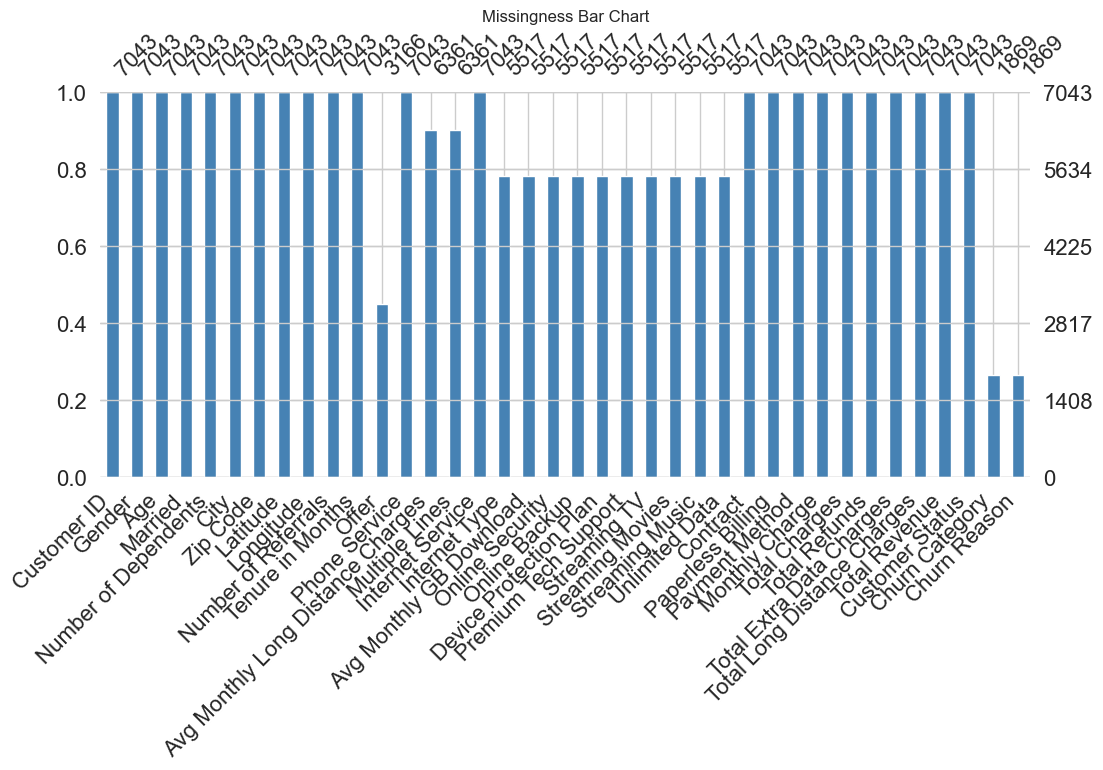

In [9]:
mano.bar(df, figsize=(12, 5), color='steelblue')
plt.title('Missingness Bar Chart')
plt.show()

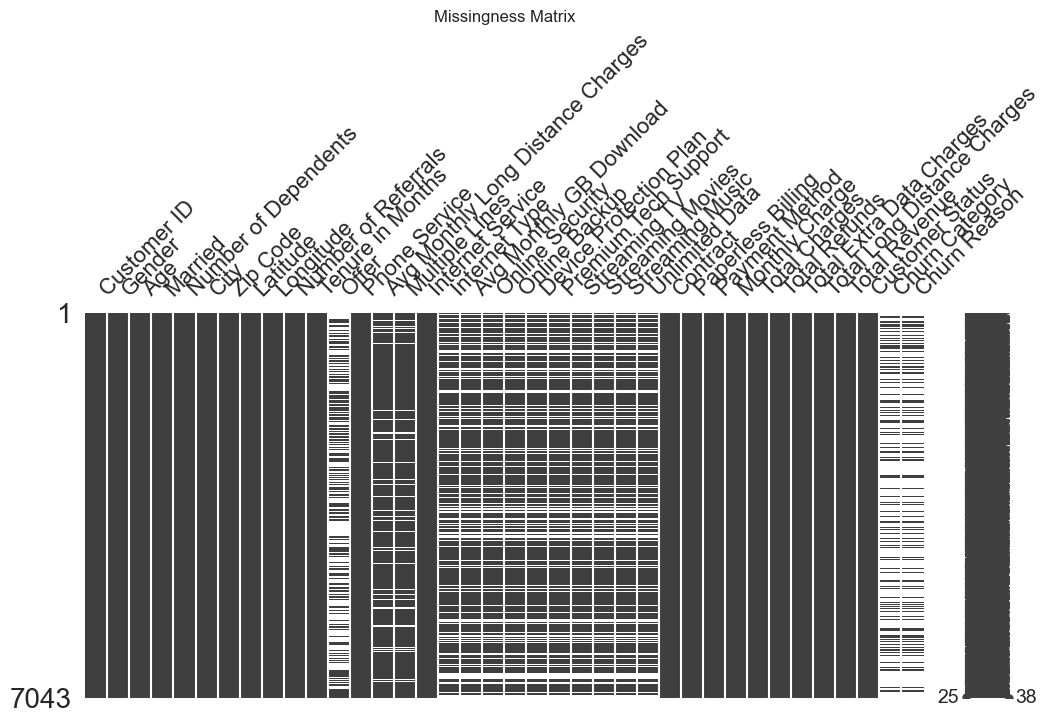

In [10]:
mano.matrix(df, figsize=(12, 5))
plt.title('Missingness Matrix')
plt.show()

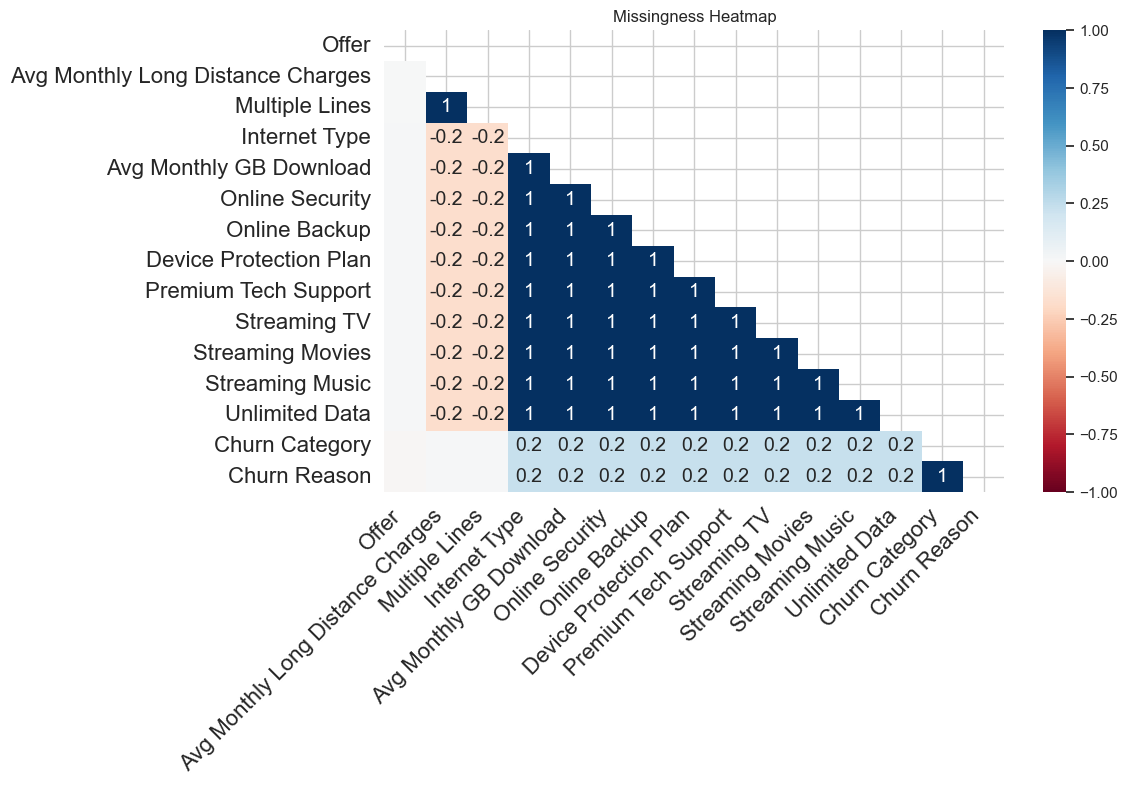

In [11]:
mano.heatmap(df, figsize=(10, 6))
plt.title('Missingness Heatmap')
plt.show()

### 2.3 Interpretation of Missingness Plots

**Bar Chart:** Shows which columns have missing values. 
Churn Category and Churn Reason have the most missing values (73%) 
followed by Offer (55%). All other columns are mostly complete.

**Matrix:** The white streaks show where values are missing. 
We can see the internet-related columns all have missing values 
at the exact same rows. This confirms these customers simply do 
not have internet service and it is not a data error.

**Heatmap:** Shows the relationship between missingness of columns.
- Score of 1.0 means those two columns are missing together. 
  All internet-related columns miss together which confirms 
  they are missing because the customer has no internet service.
- Score of -0.2 between Multiple Lines and internet columns 
  means when phone-related data is missing, internet data is present.
- Churn Category and Churn Reason miss together (1.0) because 
  only churned customers have these filled in.

**Conclusion:** All missing values in this dataset are MNAR 
(Missing Not at Random). They are missing for valid business 
reasons and not data entry errors. No imputation is needed.

## Step 3: Duplicate Check

In [12]:
duplicates = df.duplicated().sum()
print('Number of duplicate rows:', duplicates)

Number of duplicate rows: 0


### Interpretation
No duplicate rows were found in the dataset. 
All 7043 rows represent unique customers.

## Step 4: Checking for Inconsistent Values
### 4.1 Unique Values in Categorical Columns

In [13]:
cat_cols = ['Gender', 'Married', 'Offer', 'Phone Service', 
            'Internet Service', 'Internet Type', 'Contract', 
            'Paperless Billing', 'Payment Method', 'Customer Status']

for col in cat_cols:
    print(f'{col}: {df[col].unique()}')
    print()

Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str

Married: <StringArray>
['Yes', 'No']
Length: 2, dtype: str

Offer: <StringArray>
[nan, 'Offer E', 'Offer D', 'Offer A', 'Offer B', 'Offer C']
Length: 6, dtype: str

Phone Service: <StringArray>
['Yes', 'No']
Length: 2, dtype: str

Internet Service: <StringArray>
['Yes', 'No']
Length: 2, dtype: str

Internet Type: <StringArray>
['Cable', 'Fiber Optic', 'DSL', nan]
Length: 4, dtype: str

Contract: <StringArray>
['One Year', 'Month-to-Month', 'Two Year']
Length: 3, dtype: str

Paperless Billing: <StringArray>
['Yes', 'No']
Length: 2, dtype: str

Payment Method: <StringArray>
['Credit Card', 'Bank Withdrawal', 'Mailed Check']
Length: 3, dtype: str

Customer Status: <StringArray>
['Stayed', 'Churned', 'Joined']
Length: 3, dtype: str



### Interpretation
All categorical columns have consistent and valid values. 
No typos, extra spaces or inconsistent capitalization was found.
The nan values visible in Offer and Internet Type are the 
expected missing values we already identified in the MVA step.

### 4.2 Checking Numerical Columns for Invalid Values

In [14]:
num_cols = ['Age', 'Tenure in Months', 'Monthly Charge', 
            'Total Charges', 'Total Revenue', 'Number of Dependents',
            'Number of Referrals']

for col in num_cols:
    neg_count = (df[col] < 0).sum()
    print(f'{col} -- Negative values: {neg_count}')

Age -- Negative values: 0
Tenure in Months -- Negative values: 0
Monthly Charge -- Negative values: 120
Total Charges -- Negative values: 0
Total Revenue -- Negative values: 0
Number of Dependents -- Negative values: 0
Number of Referrals -- Negative values: 0


In [15]:
neg_monthly = df[df['Monthly Charge'] < 0]
print('Count:', len(neg_monthly))
print()
print(neg_monthly[['Customer ID', 'Monthly Charge', 
                    'Internet Service', 'Phone Service', 
                    'Customer Status']].head(10))

Count: 120

    Customer ID  Monthly Charge Internet Service Phone Service Customer Status
1    0003-MKNFE            -4.0              Yes           Yes          Stayed
32   0052-DCKON            -2.0              Yes           Yes          Stayed
170  0274-JKUJR            -3.0              Yes            No          Stayed
232  0361-HJRDX            -8.0              Yes            No          Stayed
336  0495-ZBNGW            -1.0              Yes           Yes         Churned
428  0623-IIHUG           -10.0              Yes            No         Churned
571  0840-DCNZE            -2.0              Yes           Yes          Stayed
692  1024-GUALD            -4.0              Yes            No         Churned
694  1024-VRZHF            -7.0              Yes           Yes         Churned
702  1036-GUDCL            -9.0              Yes           Yes          Stayed


In [16]:
neg_monthly = df[df['Monthly Charge'] < 0]
print(neg_monthly[['Customer ID', 'Monthly Charge', 
                    'Offer', 'Contract', 
                    'Customer Status']].head(20))

     Customer ID  Monthly Charge    Offer        Contract Customer Status
1     0003-MKNFE            -4.0      NaN  Month-to-Month          Stayed
32    0052-DCKON            -2.0      NaN        One Year          Stayed
170   0274-JKUJR            -3.0  Offer E  Month-to-Month          Stayed
232   0361-HJRDX            -8.0  Offer A        Two Year          Stayed
336   0495-ZBNGW            -1.0      NaN  Month-to-Month         Churned
428   0623-IIHUG           -10.0      NaN  Month-to-Month         Churned
571   0840-DCNZE            -2.0  Offer B        One Year          Stayed
692   1024-GUALD            -4.0  Offer E  Month-to-Month         Churned
694   1024-VRZHF            -7.0  Offer D  Month-to-Month         Churned
702   1036-GUDCL            -9.0      NaN  Month-to-Month          Stayed
734   1084-UQCHV            -7.0  Offer E  Month-to-Month         Churned
900   1307-TVUFB            -5.0      NaN        One Year          Stayed
934   1353-LJWEM           -10.0  Offe

In [17]:
print('Negative Monthly Charge - Offer breakdown:')
print(neg_monthly['Offer'].value_counts(dropna=False))

Negative Monthly Charge - Offer breakdown:
Offer
NaN        77
Offer E    14
Offer B     9
Offer D     9
Offer A     7
Offer C     4
Name: count, dtype: int64


In [18]:
print(neg_monthly[['Customer ID', 'Monthly Charge', 
                    'Total Charges', 'Total Refunds',
                    'Total Extra Data Charges',
                    'Total Long Distance Charges',
                    'Total Revenue']].head(10))

    Customer ID  Monthly Charge  Total Charges  Total Refunds  \
1    0003-MKNFE            -4.0         542.40          38.33   
32   0052-DCKON            -2.0        7942.15           0.00   
170  0274-JKUJR            -3.0         465.70           0.00   
232  0361-HJRDX            -8.0        4539.60           0.00   
336  0495-ZBNGW            -1.0         343.95           0.00   
428  0623-IIHUG           -10.0         840.10           0.00   
571  0840-DCNZE            -2.0        4138.90           0.00   
692  1024-GUALD            -4.0          24.80           0.00   
694  1024-VRZHF            -7.0         825.70           0.00   
702  1036-GUDCL            -9.0        4663.40           0.00   

     Total Extra Data Charges  Total Long Distance Charges  Total Revenue  
1                          10                        96.21         610.28  
32                          0                      2888.82       10830.97  
170                         0                         0.

In [19]:
neg_monthly = df[df['Monthly Charge'] < 0]
print(neg_monthly[['Customer ID', 'Monthly Charge', 
                    'Total Refunds',
                    'Total Charges',
                    'Tenure in Months']].describe())

       Monthly Charge  Total Refunds  Total Charges  Tenure in Months
count      120.000000     120.000000     120.000000        120.000000
mean        -5.416667       3.176667    2028.856250         29.766667
std          2.888934       9.855009    2120.436069         24.643929
min        -10.000000       0.000000      19.400000          1.000000
25%         -8.000000       0.000000     343.025000          7.000000
50%         -5.000000       0.000000    1325.975000         22.500000
75%         -3.000000       0.000000    3239.512500         54.000000
max         -1.000000      49.240000    7942.150000         72.000000


In [20]:
print('Average Refunds - Negative Monthly Charge customers:')
print(df[df['Monthly Charge'] < 0]['Total Refunds'].mean())

print('\nAverage Refunds - Normal customers:')
print(df[df['Monthly Charge'] >= 0]['Total Refunds'].mean())

Average Refunds - Negative Monthly Charge customers:
3.176666666666667

Average Refunds - Normal customers:
1.9411310125668064


### Interpretation
120 customers have negative Monthly Charges. 
We thoroughly investigated all possible explanations.

Findings:
- 43 customers have an active Offer which may suggest 
  a promotional discount. 77 have no offer attached.
- Average Total Refunds for negative charge customers 
  is 3.17 vs 1.94 for normal customers. The difference 
  is not significant enough to confirm overpayment as 
  the cause.
- Total Charges and Total Revenue are all positive 
  so the issue is isolated to Monthly Charge only.
- No other column in the dataset explains this pattern.

Conclusion: The reason for negative Monthly Charges 
cannot be confirmed from the data alone. These 120 
records will be kept as they are since removing them 
without a confirmed reason would cause loss of 
information. This is flagged as a data quality issue 
that would need to be confirmed with the business.

## Step 5: Validation Summary

In [21]:
print('FINAL VALIDATION SUMMARY')
print(f'Total Rows: {df.shape[0]}')
print(f'Total Columns: {df.shape[1]}')
print(f'Duplicate Rows: {df.duplicated().sum()}')
print(f'Total Missing Values: {df.isnull().sum().sum()}')
print(f'Columns with Missing Values: {df.isnull().any().sum()}')
print(f'Negative Monthly Charges: {(df["Monthly Charge"] < 0).sum()}')
print(f'Inconsistent Categorical Values: 0')
print(f'Incorrect Data Types: 0')

FINAL VALIDATION SUMMARY
Total Rows: 7043
Total Columns: 38
Duplicate Rows: 0
Total Missing Values: 30849
Columns with Missing Values: 15
Negative Monthly Charges: 120
Inconsistent Categorical Values: 0
Incorrect Data Types: 0


### Interpretation
The dataset is largely clean and well structured.

- No duplicate rows were found.
- No inconsistent categorical values or incorrect data 
  types were detected.
- 15 columns have missing values but all are MNAR 
  (Missing Not at Random) and are missing for valid 
  business reasons as confirmed by the data dictionary.
  No imputation is needed.
- 120 customers have negative Monthly Charges which 
  could not be explained from the data alone. These 
  records have been kept and flagged for awareness.

Overall the dataset is ready for EDA and BI analysis.

## Step 2 (Addition): Enriching the Data
### Merging Zip Code Population Data
Note: Ideally the merge should be performed before cleaning. 
The validation summary will be re-run on the merged dataset 
to ensure data integrity is maintained after the merge.

In [22]:
# Load the population dataset
pop_df = pd.read_csv('telecom_zipcode_population.csv')
pop_df.head()

,Zip Code,Population
0,90001,54492
1,90002,44586
2,90003,58198
3,90004,67852
4,90005,43019


In [23]:
print('Main dataset shape before merge:', df.shape)
print('Population dataset shape:', pop_df.shape)

Main dataset shape before merge: (7043, 38)
Population dataset shape: (1671, 2)


In [24]:
# Merge on Zip Code
df = df.merge(pop_df, on='Zip Code', how='left')
print('Shape after merge:', df.shape)
df.head()

Shape after merge: (7043, 39)


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Population
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN,4498
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN,31297
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices,62069
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,46677
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability,42853


In [25]:
print('Missing values in Population column after merge:')
print(df['Population'].isnull().sum())

Missing values in Population column after merge:
0


### Re-Validation After Merge

In [26]:
print('VALIDATION SUMMARY AFTER MERGE')
print(f'Total Rows: {df.shape[0]}')
print(f'Total Columns: {df.shape[1]}')
print(f'Duplicate Rows: {df.duplicated().sum()}')
print(f'Total Missing Values: {df.isnull().sum().sum()}')
print(f'Columns with Missing Values: {df.isnull().any().sum()}')
print(f'Missing in Population Column: {df["Population"].isnull().sum()}')
print(f'Negative Monthly Charges: {(df["Monthly Charge"] < 0).sum()}')

VALIDATION SUMMARY AFTER MERGE
Total Rows: 7043
Total Columns: 39
Duplicate Rows: 0
Total Missing Values: 30849
Columns with Missing Values: 15
Missing in Population Column: 0
Negative Monthly Charges: 120


### Interpretation
The merge was successful. The Population column was added 
from the Zip Code Population dataset with no missing values 
and no new duplicates introduced. All previous validation 
findings remain unchanged. The dataset is now enriched and 
ready for EDA.

## Step 6: Publishing - Save Clean Enriched Dataset

In [27]:
df.to_csv('telecom_customer_churn_clean.csv', index=False)
print('Clean enriched dataset saved successfully!')
print('Final Shape:', df.shape)

Clean enriched dataset saved successfully!
Final Shape: (7043, 39)


# Exploratory Data Analysis (EDA)
## Step 1: Descriptive Statistics

In [28]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Population
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056,22139.603294
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542,21152.392837
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000,11.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000,2344.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000,17554.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,36125.000000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,105285.000000


### Interpretation

Key observations from descriptive statistics:

**Age:** Ranges from 19 to 80 with a mean of 46.5 years. 
The distribution appears fairly balanced around the mean.

**Tenure in Months:** Ranges from 1 to 72 months with a 
mean of 32 months. 25% of customers have been with the 
company for less than 9 months indicating a large new 
customer base.

**Monthly Charge:** Ranges from -10 to 118.75 with a mean 
of $63.60. The negative values are the 120 flagged cases 
from our cleaning step.

**Total Charges:** Ranges from 18.80 to 8684.80 with a 
mean of 2280. High standard deviation of 2266 indicates 
a wide spread in customer spending.

**Total Revenue:** Mean of 3034 with a high std of 2865 
suggesting significant variation in customer value.

**Number of Referrals:** Mean of 1.95 but 50% of customers 
have 0 referrals meaning most customers do not refer others.

**Population:** Ranges from 11 to 105285 showing customers 
come from both very small and very large zip code areas.

## Step 2: Univariate Analysis
### 2.1 Distribution of Numerical Variables

In [29]:
num_cols = ['Age', 'Tenure in Months', 'Monthly Charge', 
            'Total Charges', 'Total Revenue', 
            'Number of Referrals', 'Population']

for col in num_cols:
    print(f'--- {col} ---')
    print(f'  Mean:     {df[col].mean():.2f}')
    print(f'  Median:   {df[col].median():.2f}')
    print(f'  Std Dev:  {df[col].std():.2f}')
    print(f'  Skewness: {df[col].skew():.4f}')
    print(f'  Kurtosis: {df[col].kurt():.4f}')
    print()

--- Age ---
  Mean:     46.51
  Median:   46.00
  Std Dev:  16.75
  Skewness: 0.1622
  Kurtosis: -1.0028

--- Tenure in Months ---
  Mean:     32.39
  Median:   29.00
  Std Dev:  24.54
  Skewness: 0.2405
  Kurtosis: -1.3871

--- Monthly Charge ---
  Mean:     63.60
  Median:   70.05
  Std Dev:  31.20
  Skewness: -0.2754
  Kurtosis: -1.1258

--- Total Charges ---
  Mean:     2280.38
  Median:   1394.55
  Std Dev:  2266.22
  Skewness: 0.9638
  Kurtosis: -0.2277

--- Total Revenue ---
  Mean:     3034.38
  Median:   2108.64
  Std Dev:  2865.20
  Skewness: 0.9194
  Kurtosis: -0.2035

--- Number of Referrals ---
  Mean:     1.95
  Median:   0.00
  Std Dev:  3.00
  Skewness: 1.4461
  Kurtosis: 0.7220

--- Population ---
  Mean:     22139.60
  Median:   17554.00
  Std Dev:  21152.39
  Skewness: 0.9129
  Kurtosis: 0.3255



### Interpretation
Age is fairly symmetric with mean and median both at ~46. 
Tenure in Months and Monthly Charge show mild skew. 
Total Charges, Total Revenue and Population are all 
right skewed meaning a small group of high value 
long tenure customers pull the averages up. 
Number of Referrals has the highest skew (1.45) 
with a median of 0 meaning most customers make 
no referrals at all.

### 2.2 Histograms

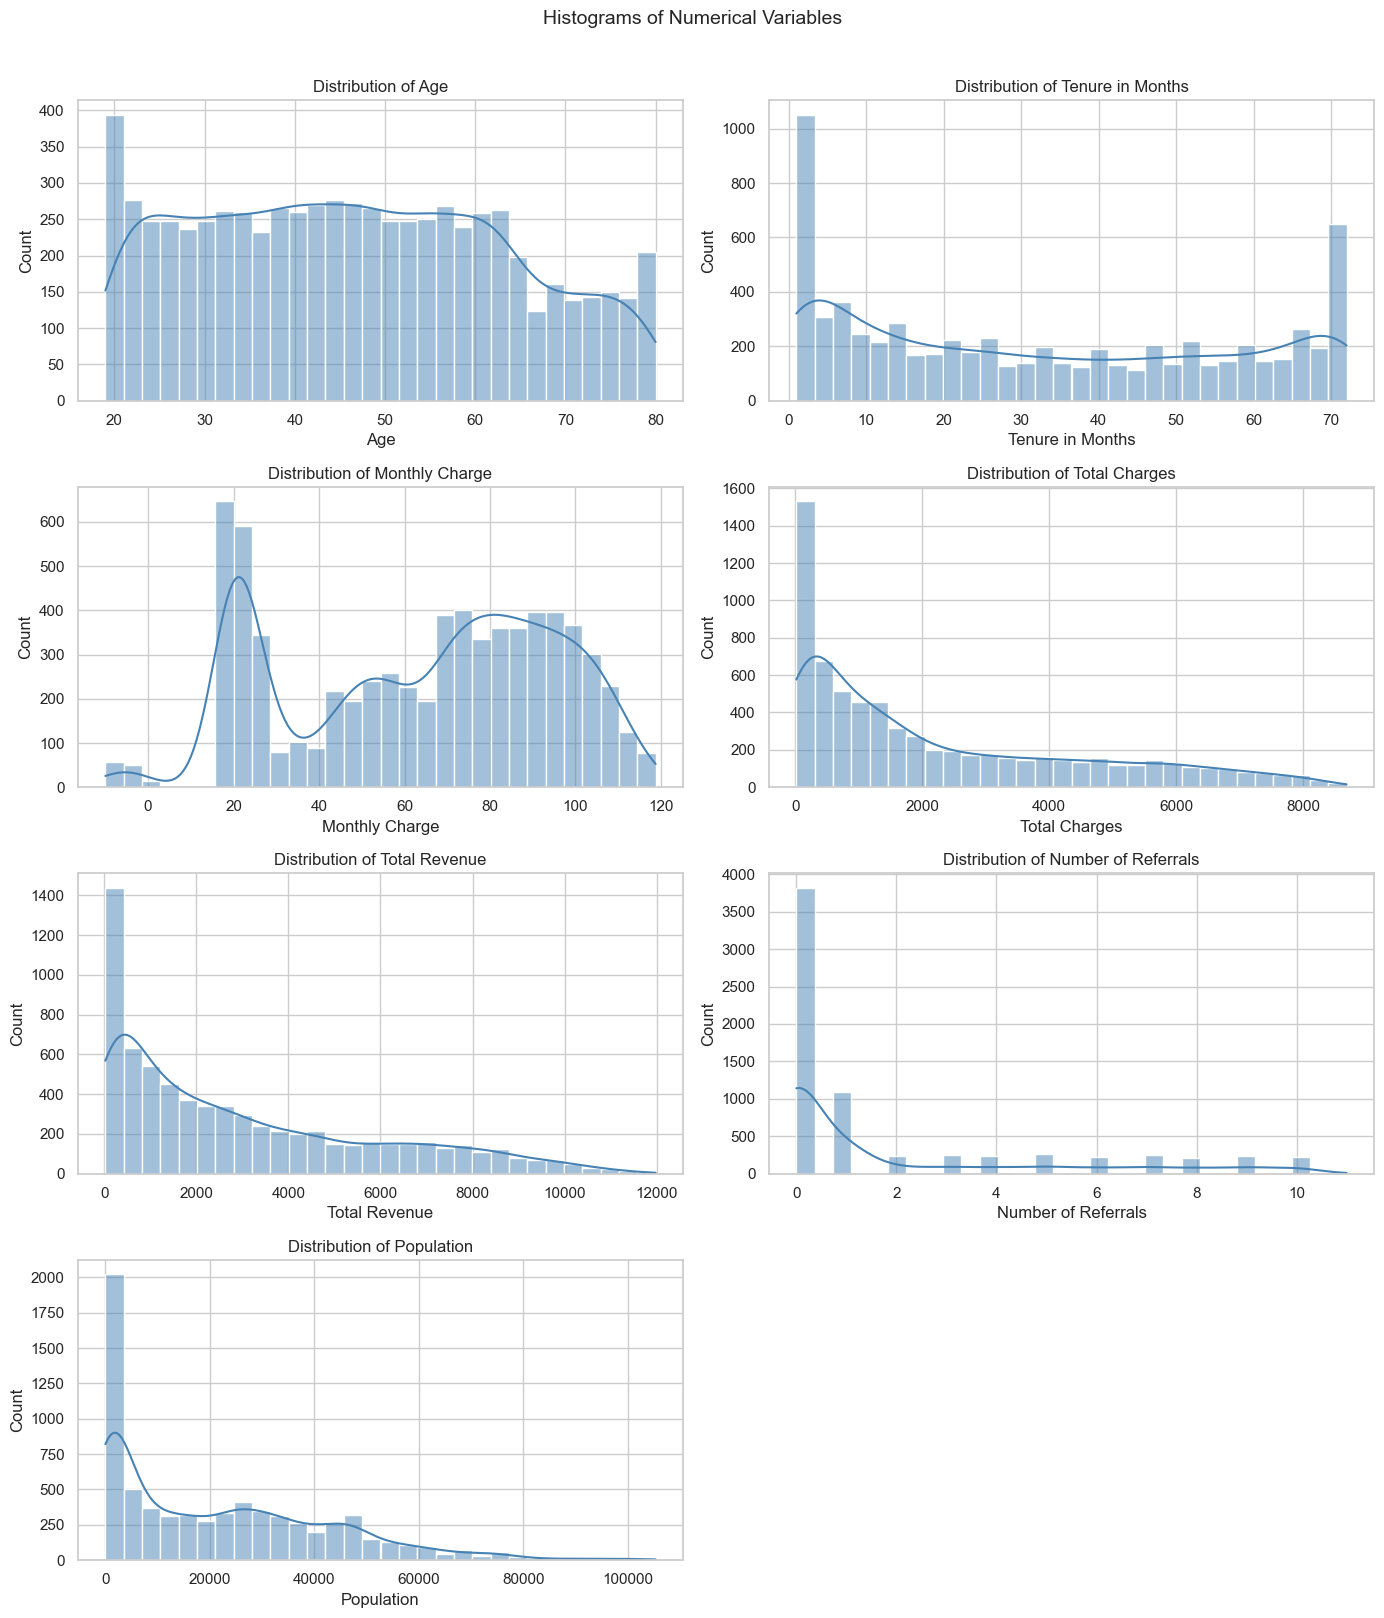

In [31]:
num_cols = ['Age', 'Tenure in Months', 'Monthly Charge', 
            'Total Charges', 'Total Revenue', 
            'Number of Referrals', 'Population']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, 
                 ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

axes[7].set_visible(False)
plt.suptitle('Histograms of Numerical Variables', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Interpretation

**Age:** Fairly uniform distribution across all age groups 
from 19 to 80. No strong concentration at any age group.

**Tenure in Months:** Large spike at the beginning (new 
customers) and another spike at 72 months (loyal customers). 
Middle tenure customers are relatively fewer.

**Monthly Charge:** Bimodal distribution with two peaks 
around 20 and 85. This suggests two distinct customer 
segments -- basic plan users and premium plan users.

**Total Charges:** Heavily right skewed with most customers 
having low total charges. A long tail of high value 
long tenure customers pulling the distribution right.

**Total Revenue:** Same pattern as Total Charges with 
strong right skew. Most customers generate modest revenue 
with a small group generating very high revenue.

**Number of Referrals:** Extremely right skewed. The vast 
majority of customers have made zero referrals. Very few 
customers are responsible for most referrals.

**Population:** Right skewed with most customers living 
in lower population zip code areas. A few customers are 
from very densely populated areas.

### 2.3 Box Plots

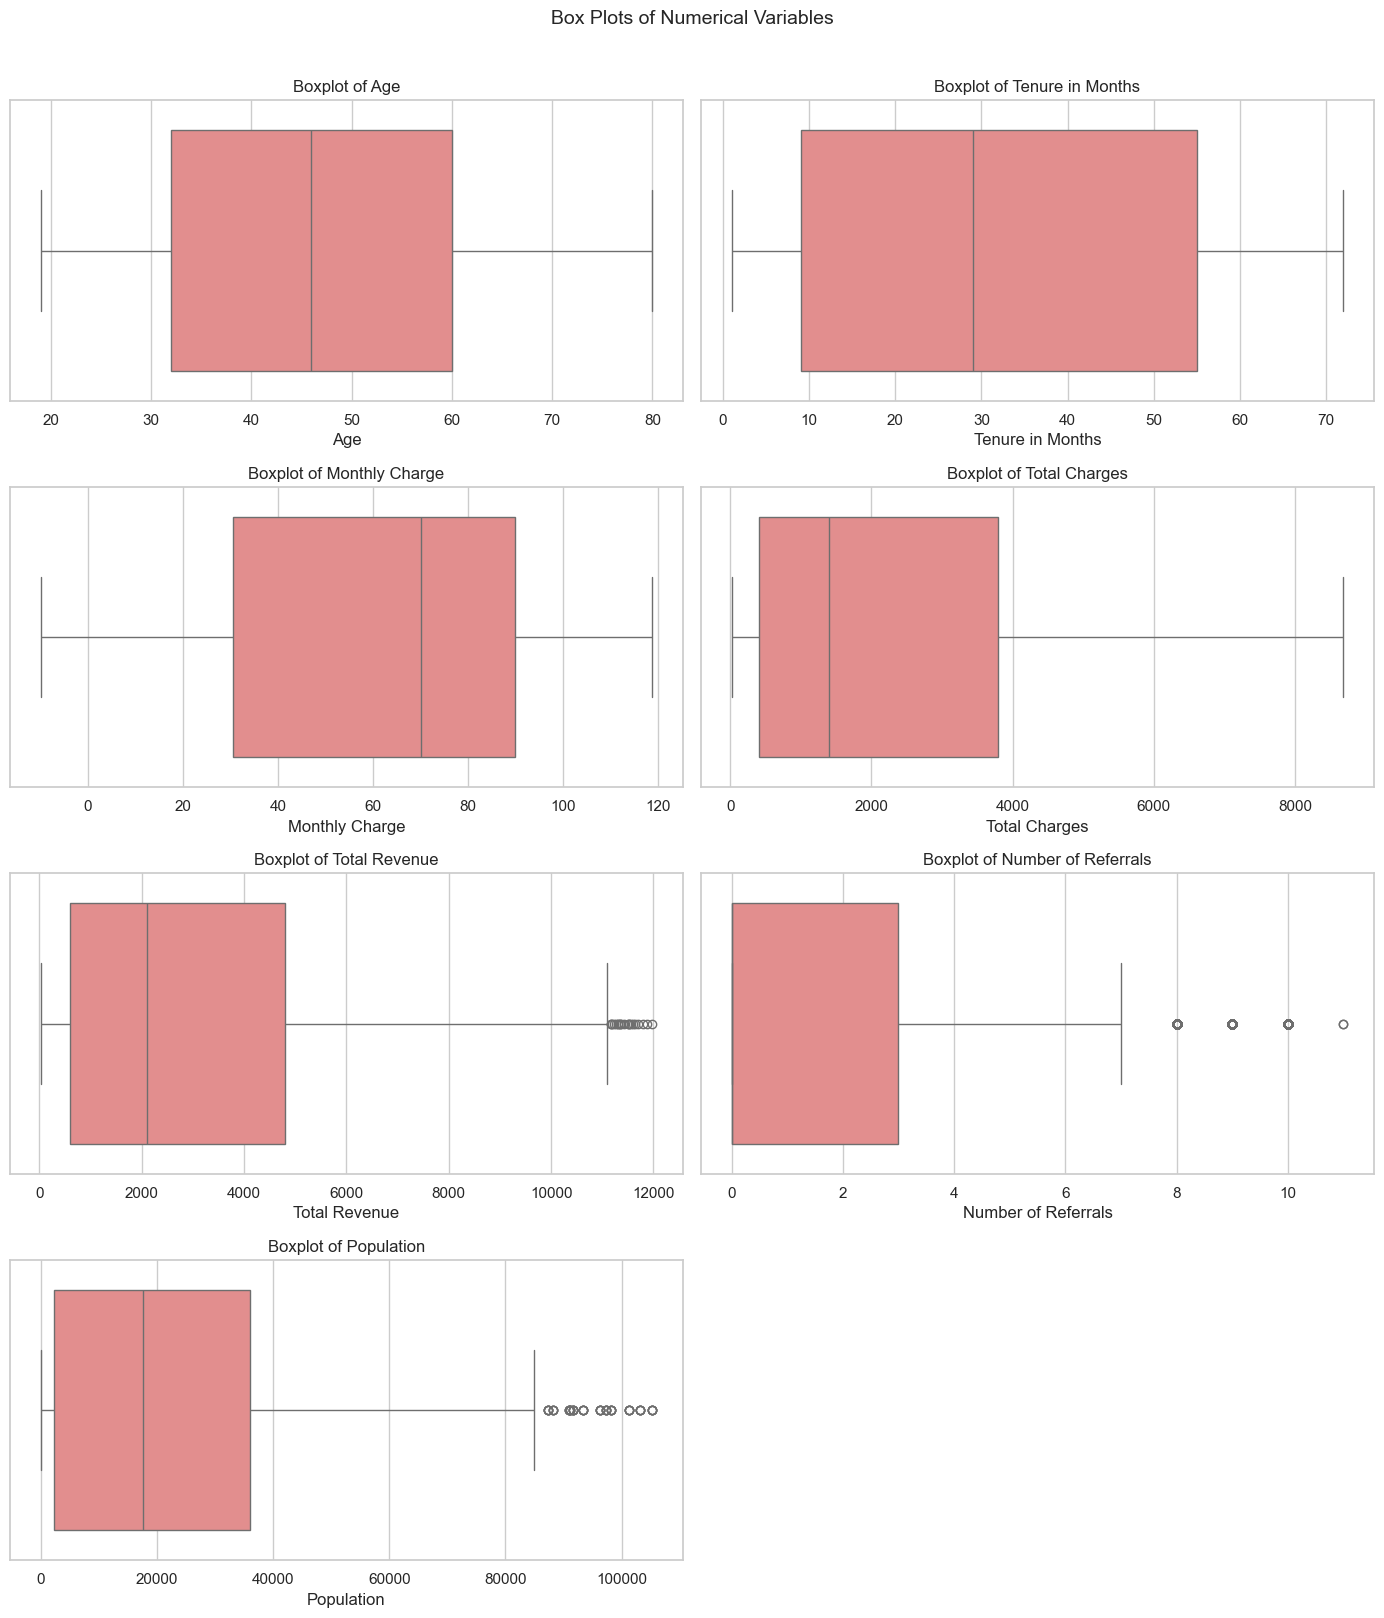

In [32]:
num_cols = ['Age', 'Tenure in Months', 'Monthly Charge', 
            'Total Charges', 'Total Revenue', 
            'Number of Referrals', 'Population']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(col)

axes[7].set_visible(False)
plt.suptitle('Box Plots of Numerical Variables', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Interpretation

**Age:** No outliers. Data is evenly spread between 19 
and 80 with the median around 46.

**Tenure in Months:** No outliers. Wide IQR indicates 
customers are spread across all tenure ranges.

**Monthly Charge:** No outliers. Wide IQR confirms the 
two customer segments seen in the histogram.

**Total Charges:** No outliers but heavily right skewed 
with a long whisker on the right side.

**Total Revenue:** A few extreme outliers on the right 
representing very high value customers generating over 
$10000 in revenue.

**Number of Referrals:** Clear outliers visible on the 
right. A small number of customers have made 8 to 11 
referrals which is far above the typical range.

**Population:** Several outliers on the right representing 
zip codes with very high populations above 80000.

## Step 3: Outlier Analysis
### 3.1 Z-Score Method

In [33]:
num_cols = ['Age', 'Tenure in Months', 'Monthly Charge', 
            'Total Charges', 'Total Revenue', 
            'Number of Referrals', 'Population']

for col in num_cols:
    z_scores = zscore(df[col].dropna())
    outliers = df[df[col].notna()]
    outliers = outliers[(abs(zscore(outliers[col])) > 3)]
    print(f'{col} -- Z-score outliers: {len(outliers)}')

Age -- Z-score outliers: 0
Tenure in Months -- Z-score outliers: 0
Monthly Charge -- Z-score outliers: 0
Total Charges -- Z-score outliers: 0
Total Revenue -- Z-score outliers: 5
Number of Referrals -- Z-score outliers: 2
Population -- Z-score outliers: 57


### 3.2 IQR Method

In [34]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}:')
    print(f'  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
    print(f'  Bounds: [{lower:.2f}, {upper:.2f}]')
    print(f'  IQR Outliers: {len(outliers)}')
    print()

Age:
  Q1=32.00, Q3=60.00, IQR=28.00
  Bounds: [-10.00, 102.00]
  IQR Outliers: 0

Tenure in Months:
  Q1=9.00, Q3=55.00, IQR=46.00
  Bounds: [-60.00, 124.00]
  IQR Outliers: 0

Monthly Charge:
  Q1=30.40, Q3=89.75, IQR=59.35
  Bounds: [-58.63, 178.78]
  IQR Outliers: 0

Total Charges:
  Q1=400.15, Q3=3786.60, IQR=3386.45
  Bounds: [-4679.52, 8866.27]
  IQR Outliers: 0

Total Revenue:
  Q1=605.61, Q3=4801.15, IQR=4195.54
  Bounds: [-5687.69, 11094.45]
  IQR Outliers: 21

Number of Referrals:
  Q1=0.00, Q3=3.00, IQR=3.00
  Bounds: [-4.50, 7.50]
  IQR Outliers: 676

Population:
  Q1=2344.00, Q3=36125.00, IQR=33781.00
  Bounds: [-48327.50, 86796.50]
  IQR Outliers: 57



### Interpretation

Comparing both methods:

**Age, Tenure in Months, Monthly Charge, Total Charges:**
Both methods agree -- no outliers detected. These variables 
are well distributed within expected ranges.

**Total Revenue:**
Z-score detected 5 outliers and IQR detected 21. These are 
very high value customers generating over $11000 in revenue. 
These are valid and important business cases representing 
the company's most valuable customers. They will be kept.

**Number of Referrals:**
Z-score detected 2 outliers but IQR detected 676. The large 
difference is because most customers have 0 referrals making 
the IQR very small and sensitive. Customers with 8 to 11 
referrals are flagged but these are genuinely highly engaged 
customers. They will be kept as they represent valuable 
customer behavior.

**Population:**
Both methods agree on 57 outliers. These are zip codes with 
very high populations above 80000. These are valid 
geographical data points and will be kept.

**Overall Conclusion:** No outliers will be removed. 
All detected outliers represent valid and meaningful 
business cases. Removal would cause loss of important 
information about high value customers and highly 
populated areas.

## Step 4: Bivariate Analysis
### 4.1 Customer Status Distribution

Customer Status Distribution:
Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

Percentage:
Customer Status
Stayed     67.02
Churned    26.54
Joined      6.45
Name: proportion, dtype: float64


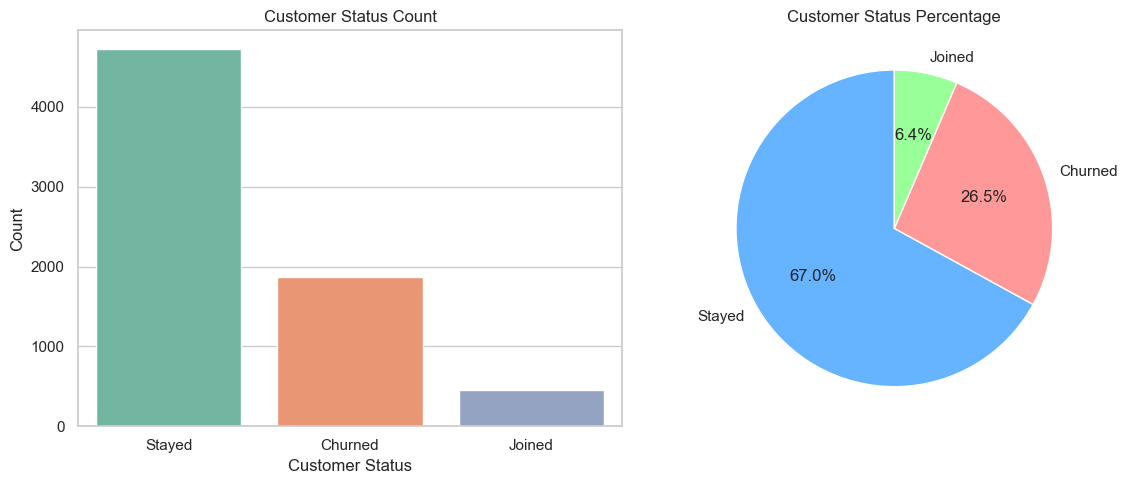

In [35]:
status_counts = df['Customer Status'].value_counts()
status_pct = df['Customer Status'].value_counts(normalize=True) * 100

print('Customer Status Distribution:')
print(status_counts)
print()
print('Percentage:')
print(status_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Customer Status', data=df, 
              palette='Set2', ax=axes[0])
axes[0].set_title('Customer Status Count')
axes[0].set_xlabel('Customer Status')
axes[0].set_ylabel('Count')

axes[1].pie(status_counts, labels=status_counts.index, 
            autopct='%1.1f%%', colors=['#66b3ff','#ff9999','#99ff99'],
            startangle=90)
axes[1].set_title('Customer Status Percentage')

plt.tight_layout()
plt.show()

### Interpretation
Out of 7043 customers in Q2 2022:
- 4720 (67%) stayed with the company
- 1869 (26.54%) churned 
- 454 (6.45%) newly joined

The churn rate of 26.54% is significantly high meaning 
the company is losing more than 1 in 4 customers every 
quarter. The new joiners (6.45%) are not enough to 
offset the churned customers which is a major concern 
for the business.

### 4.2 Churn Category and Reason Analysis

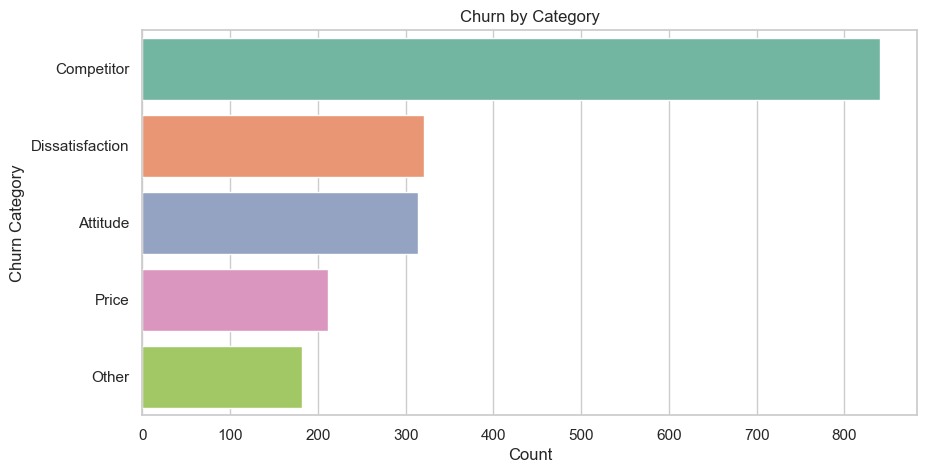

In [36]:
churn_df = df[df['Customer Status'] == 'Churned']

plt.figure(figsize=(10, 5))
sns.countplot(y='Churn Category', data=churn_df,
              order=churn_df['Churn Category'].value_counts().index,
              palette='Set2')
plt.title('Churn by Category')
plt.xlabel('Count')
plt.ylabel('Churn Category')
plt.show()

### Interpretation
Competitor is by far the biggest reason for churn with 
over 800 customers leaving for a competitor. This is 
followed by Dissatisfaction and Attitude (customer 
service issues) at around 300 each. Price and Other 
reasons are less significant.

This tells us the company is primarily losing customers 
to competition rather than internal issues. Improving 
the product offering and competitive pricing should be 
the top priority for retention.

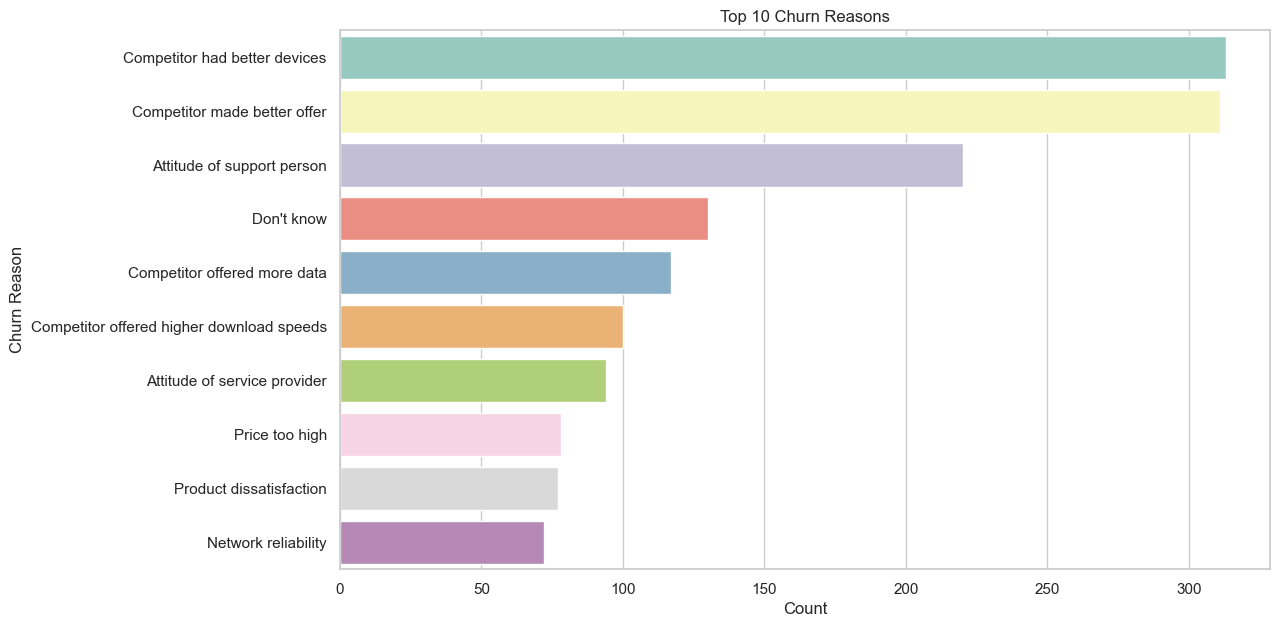

In [38]:
plt.figure(figsize=(12, 7))
sns.countplot(y='Churn Reason', data=churn_df,
              order=churn_df['Churn Reason'].value_counts().index[:10],
              palette='Set3')
plt.title('Top 10 Churn Reasons')
plt.xlabel('Count')
plt.ylabel('Churn Reason')
plt.show()

### Interpretation
The top 2 churn reasons are almost equal:
- Competitor had better devices 
- Competitor made better offer 

Attitude of support person is the third biggest reason which is an internal issue the company 
can directly address through staff training.

Other notable reasons include competitor offering more 
data and higher download speeds suggesting customers 
are leaving for better internet service quality.

Price too high and network reliability also appear 
in the top 10 indicating pricing and service quality 
are secondary concerns after competition.

These insights are highly actionable -- the company 
needs to focus on device upgrades, competitive offers 
and improving customer support attitude to reduce churn.

### 4.3 Churn by Contract Type

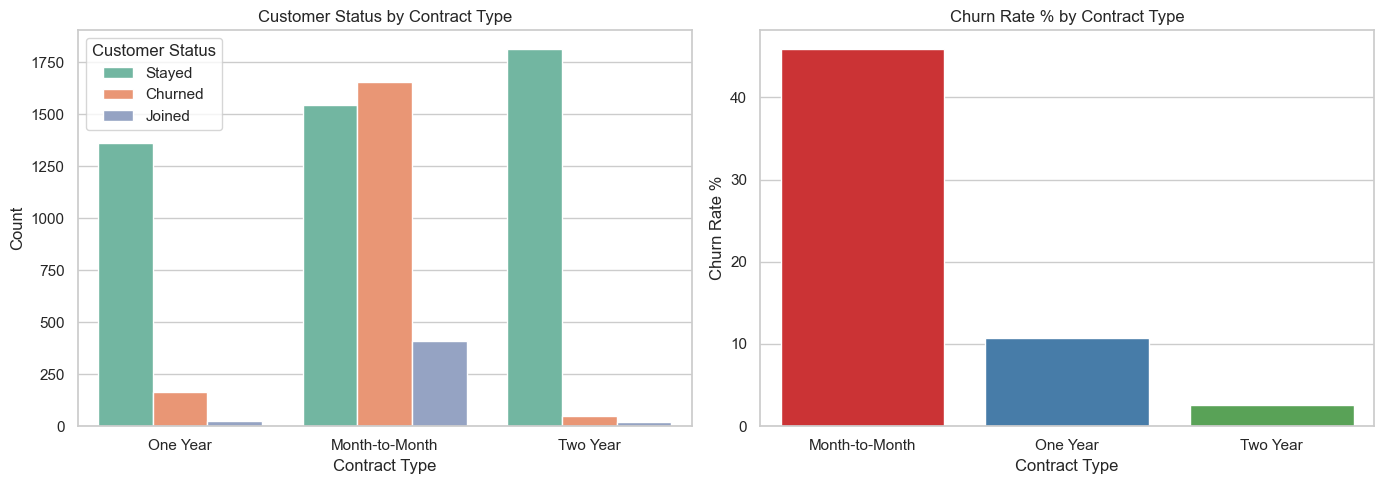

         Contract  Churn Rate %
0  Month-to-Month     45.844875
1        One Year     10.709677
2        Two Year      2.549124


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Contract', hue='Customer Status', 
              data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Customer Status by Contract Type')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Count')

churn_contract = df[df['Customer Status'] == 'Churned']
churn_rate = df.groupby('Contract')['Customer Status'].apply(
    lambda x: (x == 'Churned').sum() / len(x) * 100).reset_index()
churn_rate.columns = ['Contract', 'Churn Rate %']

sns.barplot(x='Contract', y='Churn Rate %', 
            data=churn_rate, palette='Set1', ax=axes[1])
axes[1].set_title('Churn Rate % by Contract Type')
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Churn Rate %')

plt.tight_layout()
plt.show()

print(churn_rate)

### Interpretation
Contract type is one of the strongest predictors of churn.

- Month-to-Month customers have a churn rate of 45.8% 
  meaning almost half of them leave every quarter.
- One Year contract customers have a much lower churn 
  rate of 10.7%.
- Two Year contract customers are the most loyal with 
  only 2.5% churn rate.

This is a critical business insight. Customers on 
Month-to-Month contracts are 18x more likely to churn 
than Two Year contract customers. The company should 
focus on converting Month-to-Month customers to longer 
contracts through incentives and discounts to 
significantly reduce overall churn.

Note: Although Month-to-Month contracts have more customers 
overall, the churn rate percentage accounts for group size. 
The finding remains valid -- Month-to-Month customers are 
significantly more likely to churn regardless of group size.

### 4.4 Churn by Internet Type

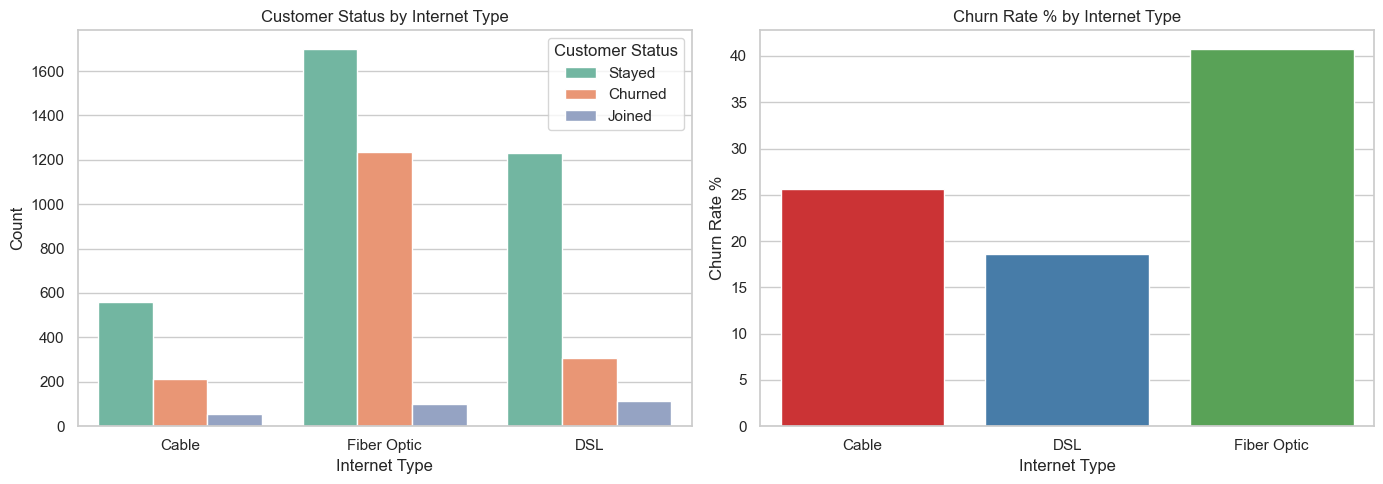

  Internet Type  Churn Rate %
0         Cable     25.662651
1           DSL     18.583535
2   Fiber Optic     40.724876


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Internet Type', hue='Customer Status',
              data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Customer Status by Internet Type')
axes[0].set_xlabel('Internet Type')
axes[0].set_ylabel('Count')

churn_internet = df.groupby('Internet Type')['Customer Status'].apply(
    lambda x: (x == 'Churned').sum() / len(x) * 100).reset_index()
churn_internet.columns = ['Internet Type', 'Churn Rate %']

sns.barplot(x='Internet Type', y='Churn Rate %',
            data=churn_internet, palette='Set1', ax=axes[1])
axes[1].set_title('Churn Rate % by Internet Type')
axes[1].set_xlabel('Internet Type')
axes[1].set_ylabel('Churn Rate %')

plt.tight_layout()
plt.show()

print(churn_internet)

### Interpretation
Fiber Optic customers have the highest churn rate at 40.7% 
which is surprising given that Fiber Optic is a premium 
service. DSL customers are the most loyal with only 18.6% 
churn rate.

This aligns with our earlier finding that customers are 
leaving because competitors offer higher download speeds 
and more data. Fiber Optic customers likely have higher 
expectations and are more aware of competitor offerings 
making them more likely to switch.

### 4.5 Churn by Tenure

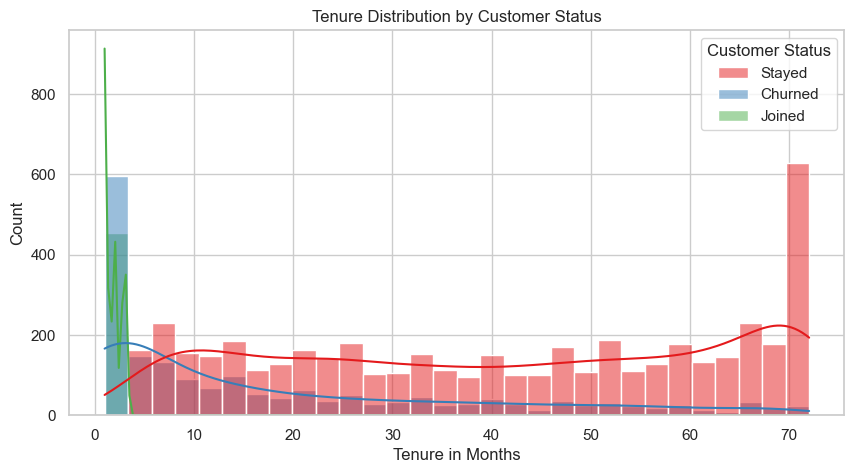

In [41]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Tenure in Months', 
             hue='Customer Status', bins=30, 
             kde=True, palette='Set1')
plt.title('Tenure Distribution by Customer Status')
plt.xlabel('Tenure in Months')
plt.ylabel('Count')
plt.show()

### Interpretation
Churned customers are heavily concentrated in the early 
months (0 to 10 months) and steadily decrease as tenure 
increases. This confirms that new customers are at the 
highest risk of churning.

Stayed customers are spread across all tenure ranges with 
a large spike at 72 months showing a strong group of 
very loyal long term customers.

Joined customers all appear at 0 to 5 months as expected 
since they are new this quarter.

The company needs stronger onboarding and early retention 
strategies to reduce churn in the first 10 months.

### 4.6 Monthly Charge vs Churn

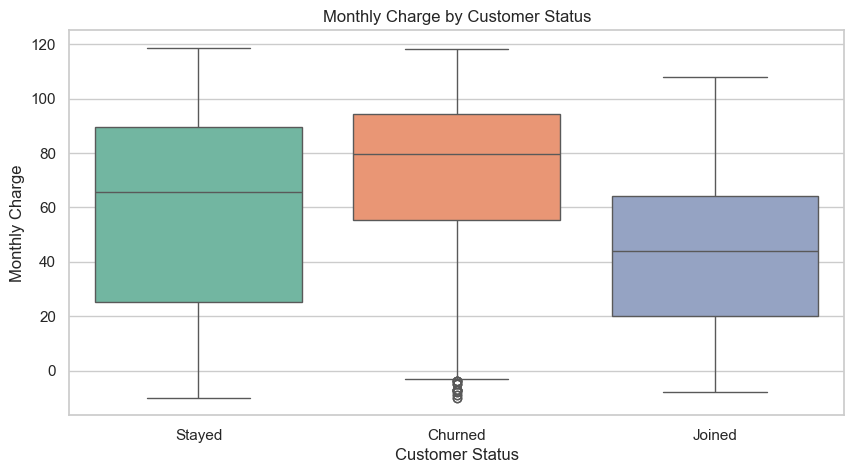

Customer Status
Churned    73.347592
Joined     42.775991
Stayed     61.737415
Name: Monthly Charge, dtype: float64


In [43]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Customer Status', y='Monthly Charge',
            data=df, palette='Set2')
plt.title('Monthly Charge by Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Monthly Charge')
plt.show()

print(df.groupby('Customer Status')['Monthly Charge'].mean())

### Interpretation
Churned customers have the highest average monthly charge 
at 73.35 compared to 61.74 for stayed customers and 
$42.78 for newly joined customers.

This suggests that customers on higher priced plans are 
more likely to churn possibly because they feel they are 
not getting enough value for the price they pay. This 
aligns with the earlier finding that price and competitor 
better offers are key churn drivers.

Newly joined customers have the lowest monthly charges 
possibly because they joined on introductory or lower 
tier plans.

## Step 5: Correlation Analysis

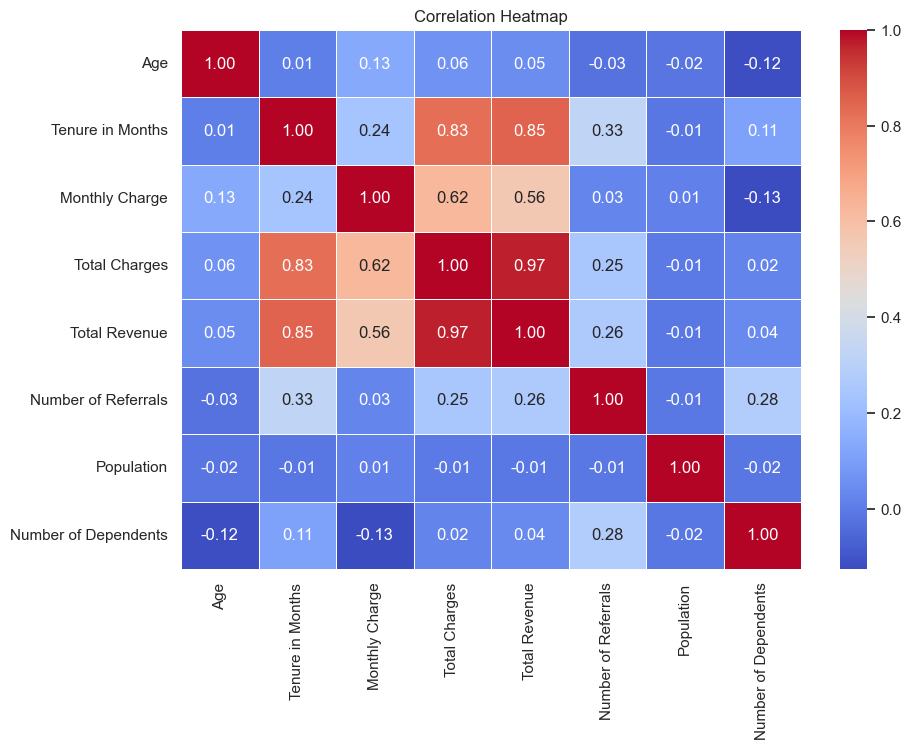

In [44]:
corr_cols = ['Age', 'Tenure in Months', 'Monthly Charge',
             'Total Charges', 'Total Revenue', 
             'Number of Referrals', 'Population',
             'Number of Dependents']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', 
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### Interpretation
Strong positive correlations:
- Tenure in Months and Total Charges (0.83) -- customers 
  who stay longer naturally accumulate higher total charges.
- Tenure in Months and Total Revenue (0.85) -- longer 
  tenure means more revenue generated for the company.
- Total Charges and Total Revenue (0.97) -- very strong 
  relationship as revenue is directly derived from charges.
- Monthly Charge and Total Charges (0.62) -- higher 
  monthly plans lead to higher total charges over time.

Notable weak correlations:
- Population has almost no correlation with any variable 
  meaning the zip code area size does not affect customer 
  behavior.
- Age has very weak correlations with all variables 
  meaning age alone is not a strong predictor.
- Number of Referrals and Number of Dependents (0.28) 
  suggesting customers with more dependents tend to 
  refer more people to the company.

## EDA Summary

The exploratory data analysis revealed the following 
key findings about telecom customer churn:

**Churn Rate:**
The company has a churn rate of 26.54% meaning more than 
1 in 4 customers left in Q2 2022. New joiners at 6.45% 
are not enough to offset this loss.

**Why Customers Churn:**
The primary reason for churn is competition. Customers 
are leaving because competitors offer better devices and 
better deals. Poor attitude of support staff is the 
biggest internal issue driving churn.

**Who is at Risk:**
- Month-to-Month contract customers churn at 45.8% 
  compared to only 2.5% for Two Year contract customers.
- Fiber Optic internet customers churn at 40.7% despite 
  paying for a premium service.
- New customers in the first 10 months are at the 
  highest risk of churning.
- Customers paying higher monthly charges are more 
  likely to churn.

**Financial Impact:**
Churned customers had an average monthly charge of 73.35 
which is higher than stayed customers at 61.74 meaning 
the company is losing its higher paying customers.

**Recommendations for BI Dashboards:**
These findings can be visualized through interactive 
dashboards in Power BI focusing on churn drivers, 
customer segmentation, contract analysis and 
financial impact of churn.

## Step 6: Statistical Tests

### 6.1 T-Test
Testing if there is a significant difference in Monthly 
Charge between Churned and Stayed customers.

H0: There is no significant difference in Monthly Charge 
between Churned and Stayed customers.
H1: There is a significant difference in Monthly Charge 
between Churned and Stayed customers.

In [45]:
from scipy import stats

churned = df[df['Customer Status'] == 'Churned']['Monthly Charge']
stayed = df[df['Customer Status'] == 'Stayed']['Monthly Charge']

t_val, p_val = stats.ttest_ind(churned, stayed)
print('T-Test: Monthly Charge (Churned vs Stayed)')
print(f'T-value: {t_val:.4f}')
print(f'P-value: {p_val:.4f}')

alpha = 0.05
if p_val <= alpha:
    print('Result: Dependent (reject H0)')
else:
    print('Result: Independent (fail to reject H0)')

T-Test: Monthly Charge (Churned vs Stayed)
T-value: 13.8561
P-value: 0.0000
Result: Dependent (reject H0)


### Interpretation
The t-test result shows a t-value of 13.86 and a p-value 
of 0.0000 which is less than the significance level of 
0.05. We reject the null hypothesis.

This confirms that there is a statistically significant 
difference in Monthly Charge between churned and stayed 
customers. Churned customers pay significantly higher 
monthly charges on average which supports our earlier 
finding that higher paying customers are more likely 
to churn.

### 6.2 ANOVA Test
Testing if Monthly Charge differs significantly across 
the three Contract Types.

H0: There is no significant difference in Monthly Charge 
across Contract Types.
H1: There is a significant difference in Monthly Charge 
across at least one Contract Type.

In [48]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Q("Monthly Charge") ~ C(Contract)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print('ANOVA: Monthly Charge vs Contract Type')
display(anova_table)

alpha = 0.05
p_val = anova_table['PR(>F)'].iloc[0]
if p_val <= alpha:
    print('Result: Dependent (reject H0)')
else:
    print('Result: Independent (fail to reject H0)')

ANOVA: Monthly Charge vs Contract Type


,sum_sq,df,F,PR(>F)
C(Contract),1.230917e+04,2.0,6.330159,0.001792
Residual,6.844740e+06,7040.0,NaN,NaN


Result: Dependent (reject H0)


### Interpretation
The ANOVA test shows an F-value of 6.33 and a p-value 
of 0.0018 which is less than the significance level of 
0.05. We reject the null hypothesis.

This confirms that Monthly Charge differs significantly 
across at least one Contract Type. This means contract 
type has a statistically significant effect on how much 
customers pay monthly which is an important finding for 
understanding churn behavior.

### 6.3 Chi-Square Test
Testing if Contract Type and Customer Status are 
independent or related.

H0: Contract Type and Customer Status are independent.
H1: Contract Type and Customer Status are dependent.

In [49]:
from scipy.stats import chi2_contingency

crosstab = pd.crosstab(df['Contract'], df['Customer Status'])
print(crosstab)

stat, p, dof, expected = chi2_contingency(crosstab)
print(f'\nDegrees of Freedom: {dof}')
print(f'P-value: {p:.4f}')

alpha = 0.05
if p <= alpha:
    print('Result: Dependent (reject H0)')
else:
    print('Result: Independent (fail to reject H0)')

Customer Status  Churned  Joined  Stayed
Contract                                
Month-to-Month      1655     408    1547
One Year             166      24    1360
Two Year              48      22    1813

Degrees of Freedom: 4
P-value: 0.0000
Result: Dependent (reject H0)


### Interpretation
The Chi-Square test shows a p-value of 0.0000 which is 
less than the significance level of 0.05. We reject the 
null hypothesis.

This confirms that Contract Type and Customer Status are 
not independent -- they are significantly related. The 
crosstab clearly shows that Month-to-Month contracts have 
1655 churned customers compared to only 48 for Two Year 
contracts. Contract type is therefore a statistically 
significant predictor of whether a customer will churn 
or stay.

Note: The p-value is not exactly zero but is so extremely 
small (4.68e-43 for t-test) that Python displays it as 
0.0000. This indicates an extraordinarily strong 
statistical significance.